In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
#from scipy.stats import boxcox
#import os
#import pickle
from sklearn.model_selection import train_test_split
import pdb
import datetime
from scipy.stats import pearsonr
import warnings
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, log_loss, f1_score, precision_score, recall_score
from sklearn.model_selection import RandomizedSearchCV
import matplotlib
from pprint import pprint
from tqdm.notebook import tqdm

# Variables categóricas

In [2]:
df=pd.read_csv(r'C:\Users\Lenovo\Desktop\Personales\Tesis_Ransomware_v2\Datos\df_ransomware1.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2916697 entries, 0 to 2916696
Data columns (total 10 columns):
 #   Column     Dtype  
---  ------     -----  
 0   address    object 
 1   year       int64  
 2   day        int64  
 3   length     int64  
 4   weight     float64
 5   count      int64  
 6   looped     int64  
 7   neighbors  int64  
 8   income     float64
 9   label      bool   
dtypes: bool(1), float64(2), int64(6), object(1)
memory usage: 203.1+ MB


In [4]:
categorical_cols = df.select_dtypes(include=['object','bool','category']).columns
for col in categorical_cols:
    print(f"\nDistribución de {col}:")
    print(df[col].value_counts())


Distribución de address:
address
1LXrSb67EaH1LGc6d6kWHq8rgv4ZBQAcpU    420
16cVG72goMe4sNqZhnpmnqfCMZ1uSFbUit    261
12wQZTDmA8onM3sEt4jwcvzDxnNXxD8Vza    207
12YursV58dRT2c9iuZg3jEWfwgTDamBcnd    183
1LEq4WmpCrqBd7V3PywE2nvFUFC3QTe52x    176
                                     ... 
14m4NjEQjLKrcjtN3doN7TgNZi3nbvPnkL      1
1CJrNRSNJepexvLFt3wSKZkzrHRag2UMCA      1
1Fsi7R5115vXKcSmFEoDUqqmEW4oT2W5AV      1
1GTkpRYXAK71c5DP2V7irDmYtvmhS46h29      1
3LFFBxp15h9KSFtaw55np8eP5fv6kdK17e      1
Name: count, Length: 2631095, dtype: int64

Distribución de label:
label
False    2875284
True       41413
Name: count, dtype: int64


# Valores atípicos

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21204\3055478358.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y=col, ax=axs[row][pos], palette='pastel')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21204\3055478358.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y=col, ax=axs[row][pos], palette='pastel')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21204\3055478358.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y=col, ax=axs[row][pos], palette='pastel')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2

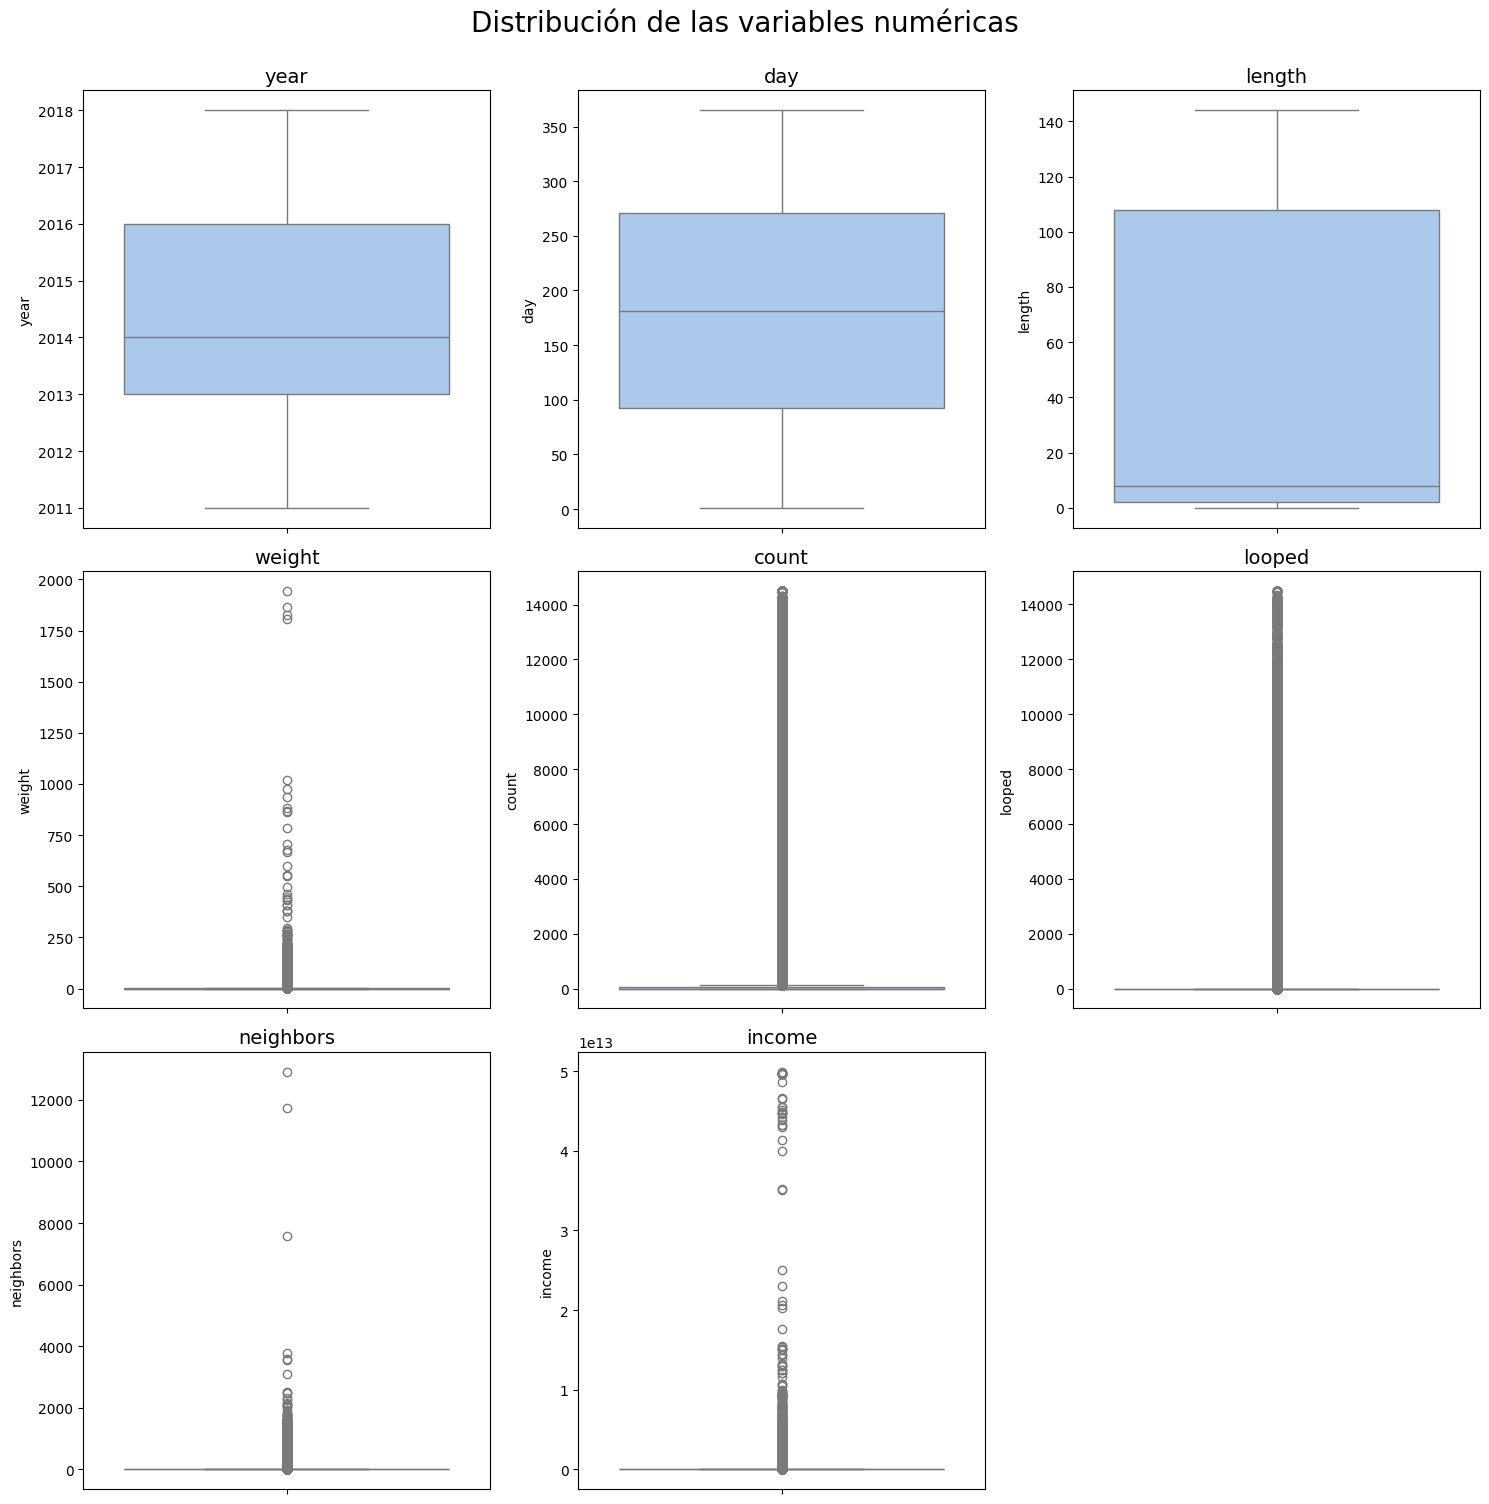

In [5]:
import math
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
# Ajustar el layout para los boxplots
num_cols = len(numerical_cols)
cols = 3  # Número de columnas para el layout de los boxplots
rows = math.ceil(num_cols / cols)  # Número de filas para el layout de los boxplots

fig, axs = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5))
fig.suptitle('Distribución de las variables numéricas', fontsize=20, y=1.0)
# Visualización con boxplot
for i, col in enumerate(numerical_cols):
    row = i // cols
    pos = i % cols
    sns.boxplot(data=df, y=col, ax=axs[row][pos], palette='pastel')
    axs[row][pos].set_title(col, fontsize=14)

# Eliminar los subplots vacíos
for j in range(i + 1, rows * cols):
    fig.delaxes(axs[j // cols][j % cols])

plt.tight_layout()
plt.savefig(r"C:\Users\Lenovo\Desktop\Personales\Tesis_Ransomware_v2\graficos\valoresatipicos.pdf", format='pdf')

# Comportamiento de las variables numéricas según ransomware

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21204\1777301062.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=col, data=df, ax=axs[row][pos], palette='pastel')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21204\1777301062.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[row][pos].legend(loc='upper right')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21204\1777301062.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=col, data=df, ax=axs[row][pos], palette='pastel')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21204\1777301062

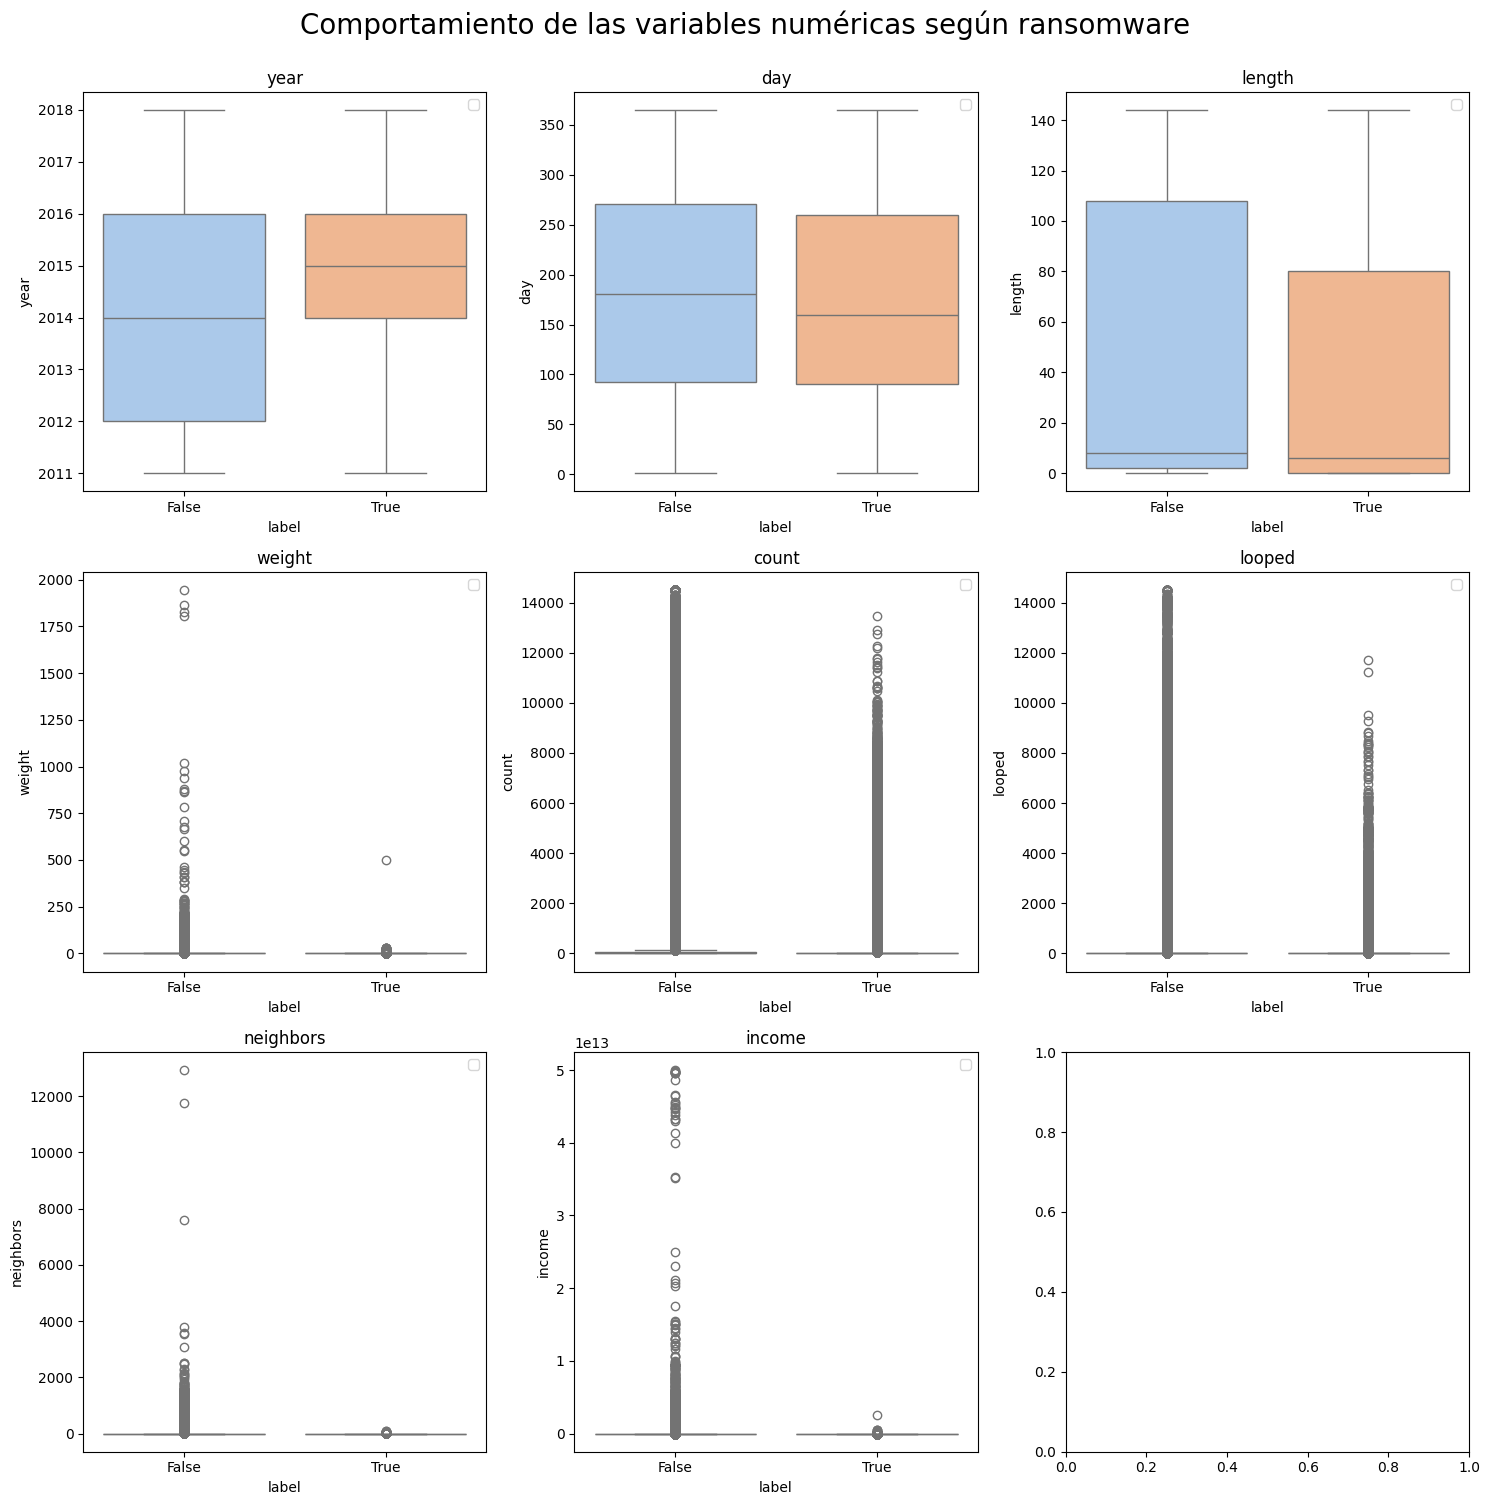

In [6]:
num_cols = len(numerical_cols)
cols = 3  # Número de columnas para el layout de los boxplots
rows = math.ceil(num_cols / cols)  # Número de filas para el layout de los boxplots
fig, axs = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5))
fig.suptitle('Comportamiento de las variables numéricas según ransomware', fontsize=20, y=1.0)

for i, col in enumerate(numerical_cols):
    row = i // 3
    pos = i % 3
    if row<6:
        sns.boxplot(x='label', y=col, data=df, ax=axs[row][pos], palette='pastel')
        axs[row][pos].set_title(col, fontsize=12)
        axs[row][pos].legend(loc='upper right')

plt.tight_layout()
plt.savefig(r"C:\Users\Lenovo\Desktop\Personales\Tesis_Ransomware_v2\graficos\numericas_ransoware.pdf", format='pdf')

# Matriz de correlación

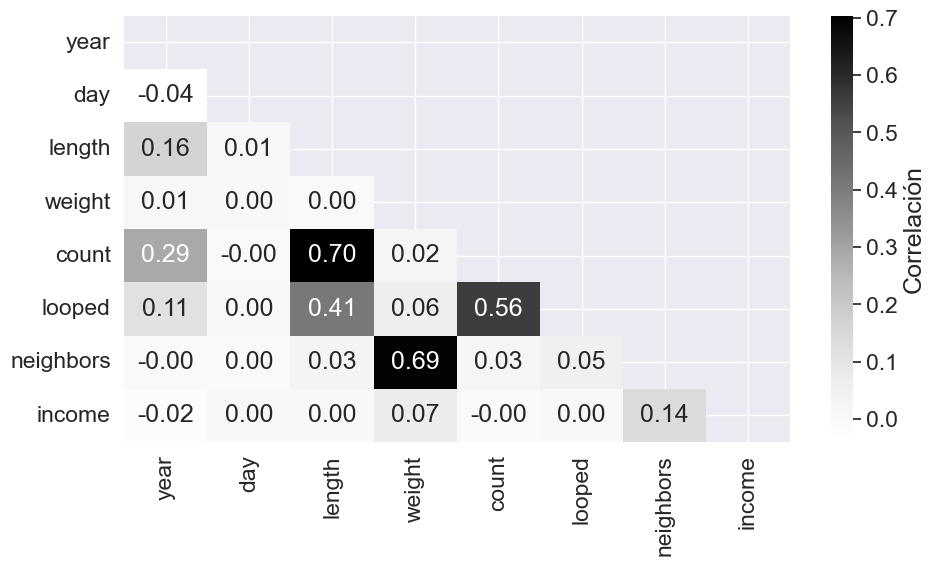

In [12]:
import matplotlib.ticker as mticker

corr_matrix = df[numerical_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 6))  # Mismo tamaño que los otros gráficos
sns.set_theme(font_scale=1.5)  # Ajusta el tamaño de fuente si lo deseas

# cmap='Greys' para tonos grises
ax = sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True, 
    fmt=".2f", 
    cmap='Greys', 
    cbar_kws={'label': 'Correlación'}
)

#plt.title('Matriz de correlación', fontsize=16)
plt.tight_layout()
plt.savefig(r"C:\Users\Lenovo\Desktop\Personales\Tesis_Ransomware_v2\graficos\matriz_correlacion.pdf", format='pdf')
plt.show()

# Variable objetivo

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21204\4046624486.py:6: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:gray'` for the same effect.

  ax = sns.countplot(data=df, x='label', hue='label', color='gray', width=0.2)


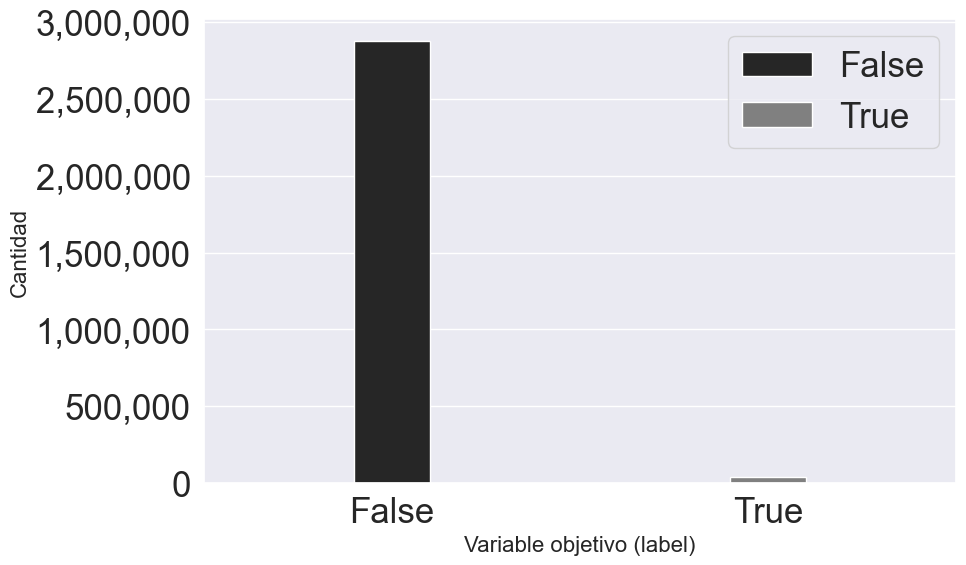

In [20]:
import matplotlib.ticker as mticker
#max_count = max(df['label'].value_counts().max(), df['year'].value_counts().max())

if 'label' in df.columns:
    plt.figure(figsize=(10, 6))
    ax = sns.countplot(data=df, x='label', hue='label', color='gray', width=0.2)
    plt.xlabel('Variable objetivo (label)', fontsize=16)
    plt.ylabel('Cantidad', fontsize=16)
    plt.xticks(fontsize=25)
    plt.yticks(fontsize=25)
    plt.legend(fontsize=25)
#    plt.ylim(0, max_count)
    #plt.title('Distribución de la variable objetivo', fontsize=16)
    
    # Formatear el eje Y para que no use notación científica
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    
    
    plt.tight_layout()
    plt.savefig(r"C:\Users\Lenovo\Desktop\Personales\Tesis_Ransomware_v2\graficos\ransomware_target.pdf", format='pdf')
    plt.show()

In [ ]:
#convertir la columna de direcciones (categórica) a enteros
cat_types = ['bool','object','category']

df[df.select_dtypes(cat_types).columns] = df.select_dtypes(cat_types).apply(lambda x: x.astype('category'))
df['address_code']=df['address'].cat.codes
#X['year_code']=X['year'].cat.codes
code_address= df.select_dtypes(exclude=['int64', 'float64'])
df = df.drop('address',errors='ignore',axis=1)
# 1. Verificar la distribución de clases original
print("=== DISTRIBUCIÓN ORIGINAL ===")
print(df['label'].value_counts())
print(f"Proporción de ransomware: {df['label'].mean():.4f}")

# 2. Verificar si hay patrones muy obvios
print("\n=== ANÁLISIS DE PATRONES ===")
print("Valores únicos por columna:")
for col in df.columns:
    if col != 'label':
        print(f"{col}: {df[col].nunique()} valores únicos")

# 3. Verificar correlación con la variable objetivo
print("\n=== CORRELACIÓN CON LABEL ===")
correlations = df.corr()['label'].abs().sort_values(ascending=False)
print(correlations)

# 4. Verificar si hay separación perfecta
print("\n=== ANÁLISIS DE SEPARABILIDAD ===")
for col in df.columns:
    if col != 'label' and df[col].dtype in ['int64', 'float64']:
        # Verificar si hay separación perfecta
        ransomware_values = df[df['label']==1][col]
        normal_values = df[df['label']==0][col]
        
        if ransomware_values.max() < normal_values.min() or ransomware_values.min() > normal_values.max():
            print(f"⚠️  SEPARACIÓN PERFECTA en {col}: Ransomware [{ransomware_values.min()}, {ransomware_values.max()}] vs Normal [{normal_values.min()}, {normal_values.max()}]")

=== DISTRIBUCIÓN ORIGINAL ===
label
0    2875284
1      41413
Name: count, dtype: int64
Proporción de ransomware: 0.0142

=== ANÁLISIS DE PATRONES ===
Valores únicos por columna:
year: 8 valores únicos
day: 365 valores únicos
length: 73 valores únicos
weight: 784927 valores únicos
count: 11572 valores únicos
looped: 10168 valores únicos
neighbors: 814 valores únicos
income: 1866365 valores únicos
address_code: 2631095 valores únicos

=== CORRELACIÓN CON LABEL ===
label           1.000000
year            0.021367
looped          0.017810
address_code    0.016943
count           0.008654
day             0.008097
length          0.006860
income          0.002716
weight          0.002676
neighbors       0.000872
Name: label, dtype: float64

=== ANÁLISIS DE SEPARABILIDAD ===


In [ ]:
#convertir la columna de direcciones (categórica) a enteros
cat_types = ['bool','object','category']

df[df.select_dtypes(cat_types).columns] = df.select_dtypes(cat_types).apply(lambda x: x.astype('category'))
df['address_code']=df['address'].cat.codes
#X['year_code']=X['year'].cat.codes
code_address= df.select_dtypes(exclude=['int64', 'float64'])
df = df.drop('address',errors='ignore',axis=1)
# 1. Verificar la distribución de clases original
print("=== DISTRIBUCIÓN ORIGINAL ===")
print(df['label'].value_counts())
print(f"Proporción de ransomware: {df['label'].mean():.4f}")

# 2. Verificar si hay patrones muy obvios
print("\n=== ANÁLISIS DE PATRONES ===")
print("Valores únicos por columna:")
for col in df.columns:
    if col != 'label':
        print(f"{col}: {df[col].nunique()} valores únicos")

# 3. Verificar correlación con la variable objetivo
print("\n=== CORRELACIÓN CON LABEL ===")
correlations = df.corr()['label'].abs().sort_values(ascending=False)
print(correlations)

# 4. Verificar si hay separación perfecta
print("\n=== ANÁLISIS DE SEPARABILIDAD ===")
for col in df.columns:
    if col != 'label' and df[col].dtype in ['int64', 'float64']:
        # Verificar si hay separación perfecta
        ransomware_values = df[df['label']==1][col]
        normal_values = df[df['label']==0][col]
        
        if ransomware_values.max() < normal_values.min() or ransomware_values.min() > normal_values.max():
            print(f"⚠️  SEPARACIÓN PERFECTA en {col}: Ransomware [{ransomware_values.min()}, {ransomware_values.max()}] vs Normal [{normal_values.min()}, {normal_values.max()}]")

=== DISTRIBUCIÓN ORIGINAL ===
label
0    2875284
1      41413
Name: count, dtype: int64
Proporción de ransomware: 0.0142

=== ANÁLISIS DE PATRONES ===
Valores únicos por columna:
year: 8 valores únicos
day: 365 valores únicos
length: 73 valores únicos
weight: 784927 valores únicos
count: 11572 valores únicos
looped: 10168 valores únicos
neighbors: 814 valores únicos
income: 1866365 valores únicos
address_code: 2631095 valores únicos

=== CORRELACIÓN CON LABEL ===
label           1.000000
year            0.021367
looped          0.017810
address_code    0.016943
count           0.008654
day             0.008097
length          0.006860
income          0.002716
weight          0.002676
neighbors       0.000872
Name: label, dtype: float64

=== ANÁLISIS DE SEPARABILIDAD ===


In [ ]:
#convertir la columna de direcciones (categórica) a enteros
cat_types = ['bool','object','category']

df[df.select_dtypes(cat_types).columns] = df.select_dtypes(cat_types).apply(lambda x: x.astype('category'))
df['address_code']=df['address'].cat.codes
#X['year_code']=X['year'].cat.codes
code_address= df.select_dtypes(exclude=['int64', 'float64'])
df = df.drop('address',errors='ignore',axis=1)
# 1. Verificar la distribución de clases original
print("=== DISTRIBUCIÓN ORIGINAL ===")
print(df['label'].value_counts())
print(f"Proporción de ransomware: {df['label'].mean():.4f}")

# 2. Verificar si hay patrones muy obvios
print("\n=== ANÁLISIS DE PATRONES ===")
print("Valores únicos por columna:")
for col in df.columns:
    if col != 'label':
        print(f"{col}: {df[col].nunique()} valores únicos")

# 3. Verificar correlación con la variable objetivo
print("\n=== CORRELACIÓN CON LABEL ===")
correlations = df.corr()['label'].abs().sort_values(ascending=False)
print(correlations)

# 4. Verificar si hay separación perfecta
print("\n=== ANÁLISIS DE SEPARABILIDAD ===")
for col in df.columns:
    if col != 'label' and df[col].dtype in ['int64', 'float64']:
        # Verificar si hay separación perfecta
        ransomware_values = df[df['label']==1][col]
        normal_values = df[df['label']==0][col]
        
        if ransomware_values.max() < normal_values.min() or ransomware_values.min() > normal_values.max():
            print(f"⚠️  SEPARACIÓN PERFECTA en {col}: Ransomware [{ransomware_values.min()}, {ransomware_values.max()}] vs Normal [{normal_values.min()}, {normal_values.max()}]")

=== DISTRIBUCIÓN ORIGINAL ===
label
0    2875284
1      41413
Name: count, dtype: int64
Proporción de ransomware: 0.0142

=== ANÁLISIS DE PATRONES ===
Valores únicos por columna:
year: 8 valores únicos
day: 365 valores únicos
length: 73 valores únicos
weight: 784927 valores únicos
count: 11572 valores únicos
looped: 10168 valores únicos
neighbors: 814 valores únicos
income: 1866365 valores únicos
address_code: 2631095 valores únicos

=== CORRELACIÓN CON LABEL ===
label           1.000000
year            0.021367
looped          0.017810
address_code    0.016943
count           0.008654
day             0.008097
length          0.006860
income          0.002716
weight          0.002676
neighbors       0.000872
Name: label, dtype: float64

=== ANÁLISIS DE SEPARABILIDAD ===


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_4356\1985556552.py:3: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:gray'` for the same effect.

  sns.countplot(data=df, x='year', hue='label', color='gray', width=1)


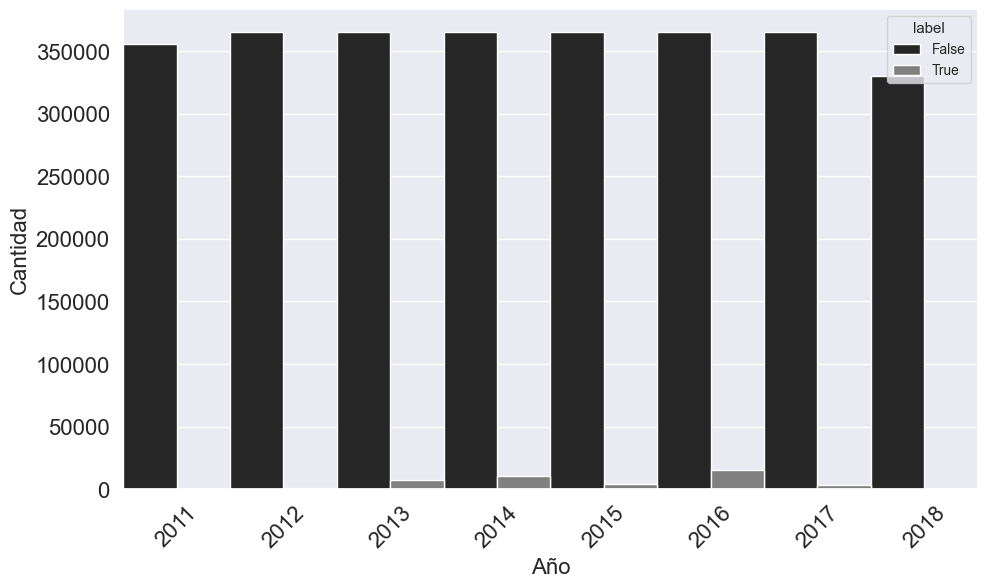

: 

In [ ]:
#max_count = max(df['label'].value_counts().max(), df['year'].value_counts().max())
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='year', hue='label', color='gray', width=1)
plt.xlabel('Año', fontsize=16)
plt.ylabel('Cantidad', fontsize=16)
plt.xticks(fontsize=16, rotation=45)
plt.yticks(fontsize=16)
#plt.ylim(0, max_count)

 # Formatear el eje Y para que no use notación científica
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
#plt.title('Distribución de registros por año', fontsize=16)
plt.tight_layout()
plt.savefig(r"C:\Users\Lenovo\Desktop\Personales\Tesis_Ransomware_v2\graficos\ransomware_año.pdf", format='pdf')
plt.show()

In [10]:
df.groupby('label').year.value_counts()

label  year
False  2012    365000
       2013    365000
       2014    365000
       2015    365000
       2016    365000
       2017    365000
       2011    355284
       2018    330000
True   2016     15631
       2014     10319
       2013      7494
       2015      3701
       2017      3486
       2012       714
       2011        65
       2018         3
Name: count, dtype: int64

In [17]:
df[['day','year']].head()

,day,year
0,11,2017
1,132,2016
2,246,2016
3,322,2016
4,238,2016
